# 01 Geo effects and ranks

Streamlined exploration notebook.

Goal: use the backend run artifacts as the source of truth, then build flexible analysis dataframes for geography, ranks, fixed-effect proxies, variance decomposition, and narrative plots.

Core idea:

1. Load canonical artifacts from `reports/runs/<run_id>/`.
2. Merge geographic metadata from `data/processed/modeling_dataset.parquet` when available.
3. Build reusable analysis tables once.
4. Explore using those tables without changing backend code.

## 00. Setup and backend ingestion

This cell is intentionally coupled to the backend layout. It assumes the canonical run structure:

```text
reports/runs/<run_id>/
  predictions/test_predictions.parquet
  predictions/validation_predictions.parquet
  metrics/model_comparison.csv
  diagnostics/*.csv
  feature_columns.json
  config_used.yaml
```

In [1]:
from pathlib import Path
import json
import yaml

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import pyarrow.parquet as pq
except Exception:
    pq = None


ROOT = Path("/home/matias/repos/income-modeling-eph")
RUNS_DIR = ROOT / "reports" / "runs"
DATASET_PATH = ROOT / "data" / "processed" / "modeling_dataset.parquet"
OUTPUT_DIR = ROOT / "reports" / "notebook_outputs" / "geo_effects_and_ranks"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)


def latest_run(pattern: str) -> Path | None:
    candidates = sorted(RUNS_DIR.glob(pattern), key=lambda p: p.name)
    if not candidates:
        return None
    return candidates[-1]


def read_csv_if_exists(path: Path) -> pd.DataFrame:
    return pd.read_csv(path) if path.exists() else pd.DataFrame()


def read_json_if_exists(path: Path):
    return json.loads(path.read_text()) if path.exists() else None


def read_yaml_if_exists(path: Path):
    return yaml.safe_load(path.read_text()) if path.exists() else None


def parquet_columns(path: Path) -> list[str]:
    if not path.exists():
        return []
    if pq is not None:
        return pq.ParquetFile(path).schema.names
    return pd.read_parquet(path, columns=None).columns.tolist()


def infer_id_col(columns) -> str:
    candidates = ["row_id", "ROW_ID", "id", "ID"]
    for col in candidates:
        if col in columns:
            return col
    raise KeyError(f"No row id column found. Available columns: {list(columns)[:40]}")


def read_predictions(run_dir: Path, split: str, experiment: str) -> pd.DataFrame:
    path = run_dir / "predictions" / f"{split}_predictions.parquet"
    if not path.exists():
        return pd.DataFrame()

    df = pd.read_parquet(path)
    df["experiment"] = experiment
    df["run_dir"] = str(run_dir)
    df["split"] = split
    df["run_id_from_path"] = run_dir.name

    if "residual" not in df.columns:
        df["residual"] = df["y_true"] - df["y_pred"]
    if "abs_error" not in df.columns:
        df["abs_error"] = df["residual"].abs()
    if "squared_error" not in df.columns:
        df["squared_error"] = df["residual"] ** 2

    return df


def read_run_bundle(experiment: str, run_dir: Path) -> dict:
    diagnostics_dir = run_dir / "diagnostics"
    metrics_dir = run_dir / "metrics"

    preds = []
    for split in ["test", "validation"]:
        df = read_predictions(run_dir, split, experiment)
        if not df.empty:
            preds.append(df)

    predictions = pd.concat(preds, ignore_index=True) if preds else pd.DataFrame()

    fe_frames = []
    for path in sorted(diagnostics_dir.glob("*fixed_effect*coefficients*.csv")):
        tmp = pd.read_csv(path)
        tmp["experiment"] = experiment
        tmp["run_dir"] = str(run_dir)
        tmp["source_file"] = path.name
        fe_frames.append(tmp)

    fixed_effect_coefficients = (
        pd.concat(fe_frames, ignore_index=True)
        if fe_frames
        else pd.DataFrame()
    )

    return {
        "experiment": experiment,
        "run_dir": run_dir,
        "predictions": predictions,
        "model_comparison": read_csv_if_exists(metrics_dir / "model_comparison.csv"),
        "residual_summary": read_csv_if_exists(diagnostics_dir / "residual_summary.csv"),
        "error_by_decile": read_csv_if_exists(diagnostics_dir / "error_by_income_decile.csv"),
        "distribution_summary": read_csv_if_exists(diagnostics_dir / "prediction_distribution_summary.csv"),
        "compression_summary": read_csv_if_exists(diagnostics_dir / "distribution_compression_summary.csv"),
        "fixed_effect_coefficients": fixed_effect_coefficients,
        "feature_columns": read_json_if_exists(run_dir / "feature_columns.json"),
        "dataset_card": read_json_if_exists(run_dir / "dataset_card.json"),
        "run_manifest": read_json_if_exists(run_dir / "run_manifest.json"),
        "config_used": read_yaml_if_exists(run_dir / "config_used.yaml"),
    }


def concat_bundle_table(bundles: dict, key: str) -> pd.DataFrame:
    frames = []

    for experiment, bundle in bundles.items():
        df = bundle.get(key)
        if df is None or len(df) == 0:
            continue

        df = df.copy()

        if "experiment" not in df.columns:
            df.insert(0, "experiment", experiment)

        if "run_dir" not in df.columns:
            df.insert(1, "run_dir", str(bundle["run_dir"]))

        frames.append(df)

    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


geo_run_patterns = {
    "clean_geo": "hgb_quick_clean_geo_v1_*",
    "no_geo": "hgb_quick_no_geo_v1_*",
    "with_geo_ranks": "hgb_quick_with_geo_ranks_v1_*",
    "shuffled_geo_ranks": "hgb_quick_shuffled_geo_ranks_v1_*",
    "region_fe": "linear_region_fe_v1_*",
    "aglo_fe": "linear_aglo_fe_v1_*",
    "year_fe": "linear_year_fe_v1_*",
    "quarter_fe": "linear_quarter_fe_v1_*",
    "aglo_year_fe": "linear_aglo_year_fe_v1_*",
}

run_dirs_raw = {
    experiment: latest_run(pattern)
    for experiment, pattern in geo_run_patterns.items()
}

missing_runs = {
    experiment: pattern
    for experiment, pattern in geo_run_patterns.items()
    if run_dirs_raw[experiment] is None
}

run_dirs = {
    experiment: run_dir
    for experiment, run_dir in run_dirs_raw.items()
    if run_dir is not None
}

bundles = {
    experiment: read_run_bundle(experiment, run_dir)
    for experiment, run_dir in run_dirs.items()
}

predictions_raw = concat_bundle_table(bundles, "predictions")
model_comparison = concat_bundle_table(bundles, "model_comparison")
residual_summary = concat_bundle_table(bundles, "residual_summary")
error_by_decile = concat_bundle_table(bundles, "error_by_decile")
distribution_summary = concat_bundle_table(bundles, "distribution_summary")
compression_summary = concat_bundle_table(bundles, "compression_summary")
fixed_effect_coefficients = concat_bundle_table(bundles, "fixed_effect_coefficients")

print("Loaded runs:")
for experiment, run_dir in run_dirs.items():
    print(f"{experiment:25s} {run_dir}")

print("\nMissing runs:")
for experiment, pattern in missing_runs.items():
    print(f"{experiment:25s} {pattern}")

print("\nLoaded tables:")
for name, df in {
    "predictions_raw": predictions_raw,
    "model_comparison": model_comparison,
    "residual_summary": residual_summary,
    "error_by_decile": error_by_decile,
    "distribution_summary": distribution_summary,
    "compression_summary": compression_summary,
    "fixed_effect_coefficients": fixed_effect_coefficients,
}.items():
    print(f"{name:32s} {df.shape}")

Loaded runs:
clean_geo                 /home/matias/repos/income-modeling-eph/reports/runs/hgb_quick_clean_geo_v1_20260611T010849Z
no_geo                    /home/matias/repos/income-modeling-eph/reports/runs/hgb_quick_no_geo_v1_20260611T011031Z
with_geo_ranks            /home/matias/repos/income-modeling-eph/reports/runs/hgb_quick_with_geo_ranks_v1_20260611T011159Z
shuffled_geo_ranks        /home/matias/repos/income-modeling-eph/reports/runs/hgb_quick_shuffled_geo_ranks_v1_20260611T011327Z
region_fe                 /home/matias/repos/income-modeling-eph/reports/runs/linear_region_fe_v1_20260609T065203Z
aglo_fe                   /home/matias/repos/income-modeling-eph/reports/runs/linear_aglo_fe_v1_20260609T065214Z
year_fe                   /home/matias/repos/income-modeling-eph/reports/runs/linear_year_fe_v1_20260609T065226Z
quarter_fe                /home/matias/repos/income-modeling-eph/reports/runs/linear_quarter_fe_v1_20260609T065239Z
aglo_year_fe              /home/matias/repos/in

## 01. Analysis dataframes

This cell creates the stable analysis layer used by the rest of the notebook.

Important choice: for this notebook, **mean residual by geographic group** is treated as a fixed-effect proxy. True fixed-effect coefficients are loaded if present, but the main exploratory object is the group-level residual pattern from archived predictions.

In [2]:
# 1. Prediction-level frame
predictions = predictions_raw.copy()

if predictions.empty:
    raise ValueError("No predictions loaded. Check run_dirs and prediction artifacts.")

ID_COL = infer_id_col(predictions.columns)

# 2. Add true/predicted deciles if needed
group_cols = ["experiment", "model", "split"]

if "true_decile" not in predictions.columns:
    predictions["true_decile"] = (
        predictions.groupby(group_cols)["y_true"]
        .transform(lambda s: pd.qcut(s, 10, labels=False, duplicates="drop") + 1)
    )

if "pred_decile" not in predictions.columns:
    predictions["pred_decile"] = (
        predictions.groupby(group_cols)["y_pred"]
        .transform(lambda s: pd.qcut(s, 10, labels=False, duplicates="drop") + 1)
    )

predictions["decile_error"] = predictions["pred_decile"] - predictions["true_decile"]
predictions["abs_decile_error"] = predictions["decile_error"].abs()

# 3. Merge geography columns from the processed modeling dataset
# This is the key bridge between backend predictions and geographic exploration.
dataset_geo = pd.DataFrame()
predictions_geo = predictions.copy()

if DATASET_PATH.exists():
    all_dataset_cols = parquet_columns(DATASET_PATH)

    geo_candidates = [
        "row_id",
        "ROW_ID",
        "AGLOMERADO",
        "Region",
        "REGION",
        "AGLO_rk",
        "Reg_rk",
        "ANO4",
        "TRIMESTRE",
        "Q",
    ]

    geo_cols = [c for c in geo_candidates if c in all_dataset_cols]

    if geo_cols:
        dataset_geo = pd.read_parquet(DATASET_PATH, columns=geo_cols).drop_duplicates()
        DATASET_ID_COL = infer_id_col(dataset_geo.columns)

        if DATASET_ID_COL != ID_COL:
            dataset_geo = dataset_geo.rename(columns={DATASET_ID_COL: ID_COL})

        predictions_geo = predictions.merge(
            dataset_geo,
            on=ID_COL,
            how="left",
            validate="many_to_one",
        )

# 4. Geo model comparison table
geo_validation_compression = (
    compression_summary
    .query("split == 'validation'")
    .copy()
    if not compression_summary.empty and "split" in compression_summary.columns
    else pd.DataFrame()
)

geo_comparison = model_comparison.copy()

compression_cols = [
    "experiment",
    "model",
    "std_ratio",
    "extreme_to_middle_mae_ratio",
    "bottom_decile_residual_mean",
    "top_decile_residual_mean",
    "tail_residual_gap",
]
compression_cols = [c for c in compression_cols if c in geo_validation_compression.columns]

if compression_cols and not geo_comparison.empty:
    geo_comparison = geo_comparison.merge(
        geo_validation_compression[compression_cols],
        on=["experiment", "model"],
        how="left",
    )

# 5. Deltas relative to no_geo
base_rows = geo_comparison.query("experiment == 'no_geo'") if "experiment" in geo_comparison.columns else pd.DataFrame()

if not base_rows.empty:
    base = base_rows.iloc[0]

    for col in [
        "validation_r2",
        "validation_mae",
        "std_ratio",
        "extreme_to_middle_mae_ratio",
        "tail_residual_gap",
    ]:
        if col in geo_comparison.columns:
            geo_comparison[f"delta_{col}_vs_no_geo"] = geo_comparison[col] - base[col]

# 6. Real rank vs shuffled rank comparison
real_vs_shuffled = pd.DataFrame()

if "experiment" in geo_comparison.columns and {"with_geo_ranks", "shuffled_geo_ranks"}.issubset(set(geo_comparison["experiment"])):
    real = geo_comparison.query("experiment == 'with_geo_ranks'").iloc[0]
    shuffled = geo_comparison.query("experiment == 'shuffled_geo_ranks'").iloc[0]

    rows = []
    for col in [
        "validation_r2",
        "validation_mae",
        "std_ratio",
        "extreme_to_middle_mae_ratio",
        "tail_residual_gap",
    ]:
        if col in geo_comparison.columns:
            rows.append(
                {
                    "metric": col,
                    "real_geo_ranks": real[col],
                    "shuffled_geo_ranks": shuffled[col],
                    "real_minus_shuffled": real[col] - shuffled[col],
                }
            )

    real_vs_shuffled = pd.DataFrame(rows)

# 7. Residuals by geographic group
geo_group_candidates = ["AGLOMERADO", "Region", "REGION"]
geo_group_cols = [c for c in geo_group_candidates if c in predictions_geo.columns]

group_residual_summary_frames = []

for group_col in geo_group_cols:
    tmp = (
        predictions_geo
        .dropna(subset=[group_col])
        .groupby(["experiment", "model", "split", group_col], dropna=False)
        .agg(
            n=("y_true", "size"),
            mean_y_true=("y_true", "mean"),
            mean_y_pred=("y_pred", "mean"),
            mean_residual=("residual", "mean"),
            median_residual=("residual", "median"),
            mae=("abs_error", "mean"),
            residual_std=("residual", "std"),
        )
        .reset_index()
        .rename(columns={group_col: "group_value"})
    )

    tmp["group_type"] = group_col
    group_residual_summary_frames.append(tmp)

group_residual_summary = (
    pd.concat(group_residual_summary_frames, ignore_index=True)
    if group_residual_summary_frames
    else pd.DataFrame()
)

if not group_residual_summary.empty:
    global_means = (
        predictions_geo
        .groupby(["experiment", "model", "split"])
        .agg(global_mean_y_true=("y_true", "mean"))
        .reset_index()
    )

    group_residual_summary = group_residual_summary.merge(
        global_means,
        on=["experiment", "model", "split"],
        how="left",
    )

    group_residual_summary["raw_gap"] = (
        group_residual_summary["mean_y_true"]
        - group_residual_summary["global_mean_y_true"]
    )

# 8. Ranks, if available
rank_cols = [c for c in ["AGLO_rk", "Reg_rk"] if c in predictions_geo.columns]
rank_summary_frames = []

for rank_col in rank_cols:
    tmp = (
        predictions_geo
        .dropna(subset=[rank_col])
        .groupby(["experiment", "model", "split", rank_col], dropna=False)
        .agg(
            n=("y_true", "size"),
            mean_y_true=("y_true", "mean"),
            mean_y_pred=("y_pred", "mean"),
            mean_residual=("residual", "mean"),
            mae=("abs_error", "mean"),
        )
        .reset_index()
        .rename(columns={rank_col: "rank_value"})
    )

    tmp["rank_type"] = rank_col
    rank_summary_frames.append(tmp)

rank_summary = (
    pd.concat(rank_summary_frames, ignore_index=True)
    if rank_summary_frames
    else pd.DataFrame()
)

fe_coefficients = fixed_effect_coefficients.copy()

print("Analysis dataframes:")
for name, df in {
    "predictions": predictions,
    "predictions_geo": predictions_geo,
    "dataset_geo": dataset_geo,
    "geo_comparison": geo_comparison,
    "real_vs_shuffled": real_vs_shuffled,
    "group_residual_summary": group_residual_summary,
    "rank_summary": rank_summary,
    "fe_coefficients": fe_coefficients,
}.items():
    print(f"{name:32s} {df.shape}")

print("\nGeo columns available in predictions_geo:")
print([c for c in ["AGLOMERADO", "Region", "REGION", "AGLO_rk", "Reg_rk", "ANO4", "TRIMESTRE", "Q"] if c in predictions_geo.columns])

print("\nFixed effect coefficient columns:")
print(fe_coefficients.columns.tolist() if not fe_coefficients.empty else "No FE coefficients loaded")

Analysis dataframes:
predictions                      (390000, 17)
predictions_geo                  (390000, 23)
dataset_geo                      (356791, 7)
geo_comparison                   (14, 16)
real_vs_shuffled                 (2, 4)
group_residual_summary           (1092, 14)
rank_summary                     (1092, 10)
fe_coefficients                  (358, 12)

Geo columns available in predictions_geo:
['AGLOMERADO', 'Region', 'AGLO_rk', 'Reg_rk', 'ANO4', 'TRIMESTRE']

Fixed effect coefficient columns:
['run_id', 'model', 'fe_name', 'level', 'feature', 'coefficient', 'abs_coefficient', 'sign', 'rank', 'experiment', 'run_dir', 'source_file']


## 02. Data status

Use this cell as a quick audit: which runs loaded, which geography columns are available, and whether FE coefficient files exist.

In [3]:
DATA_STATUS = {
    "n_predictions": len(predictions),
    "experiments": sorted(predictions["experiment"].dropna().unique().tolist()),
    "models": sorted(predictions["model"].dropna().unique().tolist()),
    "splits": sorted(predictions["split"].dropna().unique().tolist()),
    "id_col": ID_COL,
    "geo_columns_available": [
        c for c in ["AGLOMERADO", "Region", "REGION", "AGLO_rk", "Reg_rk"]
        if c in predictions_geo.columns
    ],
    "has_group_residual_summary": not group_residual_summary.empty,
    "has_rank_summary": not rank_summary.empty,
    "has_fixed_effect_coefficients": not fe_coefficients.empty,
    "missing_runs": missing_runs,
}

DATA_STATUS

{'n_predictions': 390000,
 'experiments': ['aglo_fe',
  'aglo_year_fe',
  'clean_geo',
  'no_geo',
  'quarter_fe',
  'region_fe',
  'shuffled_geo_ranks',
  'with_geo_ranks',
  'year_fe'],
 'models': ['HistGradientBoostingRegressor', 'LinearRegression', 'Ridge'],
 'splits': ['test', 'validation'],
 'id_col': 'row_id',
 'geo_columns_available': ['AGLOMERADO', 'Region', 'AGLO_rk', 'Reg_rk'],
 'has_group_residual_summary': True,
 'has_rank_summary': True,
 'has_fixed_effect_coefficients': True,
 'missing_runs': {}}

## 03. Experiment overview

Question: does geography improve global predictive performance?

This table is the high-level comparison across no geography, real ranks, shuffled ranks, clean geo, and linear fixed-effect runs.

In [4]:
overview_cols = [
    "experiment",
    "model",
    "feature_count",
    "cv_r2_mean",
    "test_r2",
    "validation_r2",
    "test_mae",
    "validation_mae",
    "std_ratio",
    "tail_residual_gap",
    "delta_validation_r2_vs_no_geo",
    "delta_validation_mae_vs_no_geo",
]

overview_cols = [c for c in overview_cols if c in geo_comparison.columns]

geo_model_table = (
    geo_comparison[overview_cols]
    .sort_values("validation_r2", ascending=False)
    .reset_index(drop=True)
)

geo_model_table.round(4)

,experiment,model,feature_count,cv_r2_mean,test_r2,validation_r2,test_mae,validation_mae,delta_validation_r2_vs_no_geo,delta_validation_mae_vs_no_geo
0,shuffled_geo_ranks,HistGradientBoostingRegressor,37,5.558000e-01,0.5772,0.5732,0.1810,0.1815,0.0133,-0.0038
1,with_geo_ranks,HistGradientBoostingRegressor,37,5.564000e-01,0.5774,0.5730,0.1807,0.1814,0.0132,-0.0039
2,clean_geo,HistGradientBoostingRegressor,35,5.553000e-01,0.5761,0.5714,0.1813,0.1819,0.0116,-0.0033
3,no_geo,HistGradientBoostingRegressor,33,5.425000e-01,0.5625,0.5598,0.1849,0.1853,0.0000,0.0000
4,year_fe,LinearRegression,38,-6.500973e+23,0.4347,0.4358,0.2113,0.2143,-0.1240,0.0290
5,year_fe,Ridge,38,4.017000e-01,0.4349,0.4358,0.2112,0.2142,-0.1241,0.0289
6,aglo_year_fe,LinearRegression,35,-3.622627e+20,0.4377,0.4343,0.2107,0.2144,-0.1255,0.0291
7,aglo_year_fe,Ridge,35,3.814000e-01,0.4379,0.4342,0.2106,0.2144,-0.1256,0.0291
8,quarter_fe,LinearRegression,38,4.086000e-01,0.4309,0.4307,0.2123,0.2152,-0.1292,0.0300
9,quarter_fe,Ridge,38,4.089000e-01,0.4310,0.4305,0.2122,0.2152,-0.1294,0.0299


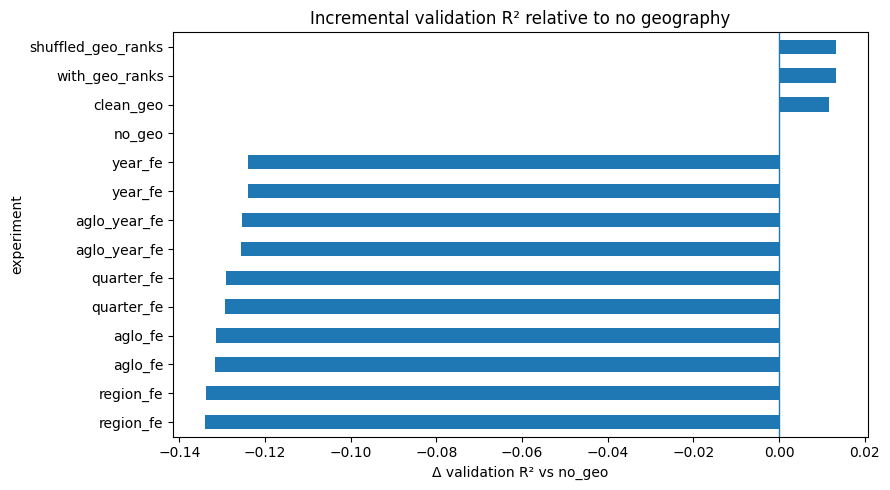

In [5]:
plot_df = geo_model_table.dropna(subset=["delta_validation_r2_vs_no_geo"]).copy()

if not plot_df.empty:
    ax = plot_df.sort_values("delta_validation_r2_vs_no_geo").plot.barh(
        x="experiment",
        y="delta_validation_r2_vs_no_geo",
        figsize=(9, 5),
        title="Incremental validation R² relative to no geography",
        legend=False,
    )
    ax.axvline(0, linewidth=1)
    ax.set_xlabel("Δ validation R² vs no_geo")
    plt.tight_layout()
else:
    print("No delta_validation_r2_vs_no_geo available.")

## 04. Group-level fixed-effect proxy dataframe

For exploratory purposes, use the mean residual by geographic group as a fixed-effect proxy:

```text
FE proxy(group) = mean(y_true - y_pred | group)
```

Positive values mean systematic underprediction for that group. Negative values mean systematic overprediction.

In [6]:
GEO_COL = "AGLOMERADO"
SPLIT = "validation"
MIN_N = 100

if group_residual_summary.empty:
    raise ValueError("group_residual_summary is empty. Check whether geography columns were merged.")

df_group = (
    group_residual_summary
    .query("group_type == @GEO_COL and split == @SPLIT")
    .copy()
)

# Keep group labels stable and readable.
df_group["group_value"] = df_group["group_value"].astype(str)
df_group["setting"] = df_group["experiment"] + " | " + df_group["model"]
df_group["abs_mean_residual"] = df_group["mean_residual"].abs()
df_group["se_mean_residual"] = df_group["residual_std"] / np.sqrt(df_group["n"])
df_group["t_like"] = df_group["mean_residual"] / df_group["se_mean_residual"]

df_group_big = df_group.query("n >= @MIN_N").copy()

REFERENCE_SETTING = "aglo_fe | LinearRegression"
if REFERENCE_SETTING not in df_group_big["setting"].unique():
    REFERENCE_SETTING = df_group_big["setting"].iloc[0]

order = (
    df_group_big
    .query("setting == @REFERENCE_SETTING")
    .sort_values("mean_y_true")
    ["group_value"]
    .tolist()
)

df_group_big["group_order"] = pd.Categorical(
    df_group_big["group_value"],
    categories=order,
    ordered=True,
)

df_group_big = df_group_big.sort_values(["group_order", "setting"])

df_group_big.head()

/tmp/ipykernel_45111/3339918149.py:35: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df_group_big["group_order"] = pd.Categorical(


,experiment,model,split,group_value,n,mean_y_true,mean_y_pred,mean_residual,median_residual,mae,residual_std,group_type,global_mean_y_true,raw_gap,setting,abs_mean_residual,se_mean_residual,t_like,group_order
40,aglo_fe,LinearRegression,validation,8,125,3.489406,3.516566,-0.027160,0.022473,0.232991,0.288213,AGLOMERADO,3.649029,-0.159623,aglo_fe | LinearRegression,0.027160,0.025779,-1.053604,8
106,aglo_fe,Ridge,validation,8,125,3.489406,3.516520,-0.027114,0.021798,0.232863,0.288089,AGLOMERADO,3.649029,-0.159623,aglo_fe | Ridge,0.027114,0.025767,-1.052248,8
172,aglo_year_fe,LinearRegression,validation,8,125,3.489406,3.517116,-0.027710,0.021246,0.234308,0.286615,AGLOMERADO,3.649029,-0.159623,aglo_year_fe | LinearRegression,0.027710,0.025636,-1.080925,8
238,aglo_year_fe,Ridge,validation,8,125,3.489406,3.517796,-0.028390,0.019298,0.234122,0.286448,AGLOMERADO,3.649029,-0.159623,aglo_year_fe | Ridge,0.028390,0.025621,-1.108107,8
304,clean_geo,HistGradientBoostingRegressor,validation,8,518,3.499371,3.519575,-0.020205,-0.017922,0.186335,0.241623,AGLOMERADO,3.646679,-0.147308,clean_geo | HistGradientBoostingRegressor,0.020205,0.010616,-1.903200,8


## 05. Effect magnitude summary

Question: are geographic residual effects large or small, and are they driven by small groups?

In [7]:
def summarize_group_effects(df: pd.DataFrame) -> pd.Series:
    return pd.Series({
        "n_groups": df["group_value"].nunique(),
        "total_n": df["n"].sum(),
        "median_abs_effect": df["mean_residual"].abs().median(),
        "mean_abs_effect": df["mean_residual"].abs().mean(),
        "p75_abs_effect": df["mean_residual"].abs().quantile(0.75),
        "p90_abs_effect": df["mean_residual"].abs().quantile(0.90),
        "max_abs_effect": df["mean_residual"].abs().max(),
        "median_group_n": df["n"].median(),
        "min_group_n": df["n"].min(),
    })


effect_magnitude_summary = (
    group_residual_summary
    .copy()
    .assign(group_value=lambda d: d["group_value"].astype(str))
    .groupby(["experiment", "model", "split", "group_type"], dropna=False)
    .apply(summarize_group_effects)
    .reset_index()
)

highlight_groups = (
    df_group_big
    .sort_values("abs_mean_residual", ascending=False)
    .head(20)
    [[
        "setting",
        "group_value",
        "n",
        "mean_y_true",
        "mean_y_pred",
        "mean_residual",
        "abs_mean_residual",
        "se_mean_residual",
        "t_like",
    ]]
)

effect_magnitude_summary.query("split == 'validation' and group_type == @GEO_COL").sort_values(
    "p90_abs_effect", ascending=False
).round(4)

,experiment,model,split,group_type,n_groups,total_n,median_abs_effect,mean_abs_effect,p75_abs_effect,p90_abs_effect,max_abs_effect,median_group_n,min_group_n
34,region_fe,LinearRegression,validation,AGLOMERADO,33.0,5000.0,0.0228,0.0291,0.0387,0.0624,0.0846,129.0,75.0
38,region_fe,Ridge,validation,AGLOMERADO,33.0,5000.0,0.0228,0.0291,0.0389,0.0624,0.0845,129.0,75.0
22,no_geo,HistGradientBoostingRegressor,validation,AGLOMERADO,33.0,20000.0,0.0199,0.0270,0.0329,0.0554,0.1394,519.0,269.0
54,year_fe,Ridge,validation,AGLOMERADO,33.0,5000.0,0.0149,0.0223,0.0336,0.0505,0.0599,129.0,75.0
50,year_fe,LinearRegression,validation,AGLOMERADO,33.0,5000.0,0.0154,0.0223,0.0326,0.0504,0.0585,129.0,75.0
30,quarter_fe,Ridge,validation,AGLOMERADO,33.0,5000.0,0.0174,0.0230,0.0331,0.0489,0.0582,129.0,75.0
26,quarter_fe,LinearRegression,validation,AGLOMERADO,33.0,5000.0,0.0176,0.0230,0.0331,0.0488,0.0581,129.0,75.0
2,aglo_fe,LinearRegression,validation,AGLOMERADO,33.0,5000.0,0.0205,0.0233,0.0312,0.0427,0.0629,129.0,75.0
6,aglo_fe,Ridge,validation,AGLOMERADO,33.0,5000.0,0.0208,0.0232,0.0317,0.0425,0.0622,129.0,75.0
14,aglo_year_fe,Ridge,validation,AGLOMERADO,33.0,5000.0,0.0174,0.0224,0.0324,0.0397,0.0636,129.0,75.0


,setting,group_value,n,mean_y_true,mean_y_pred,mean_residual,abs_mean_residual,se_mean_residual,t_like
371,no_geo | HistGradientBoostingRegressor,9,354,3.8765,3.7371,0.1394,0.1394,0.0117,11.9215
573,region_fe | LinearRegression,14,110,3.5075,3.5920,-0.0846,0.0846,0.0287,-2.9479
639,region_fe | Ridge,14,110,3.5075,3.5920,-0.0845,0.0845,0.0287,-2.9479
592,region_fe | LinearRegression,91,109,3.7041,3.7844,-0.0803,0.0803,0.0285,-2.8216
658,region_fe | Ridge,91,109,3.7041,3.7843,-0.0802,0.0802,0.0285,-2.8178
568,region_fe | LinearRegression,8,125,3.4894,3.5628,-0.0734,0.0734,0.0258,-2.8461
634,region_fe | Ridge,8,125,3.4894,3.5628,-0.0734,0.0734,0.0258,-2.8442
377,no_geo | HistGradientBoostingRegressor,17,417,3.7884,3.7197,0.0687,0.0687,0.0139,4.9474
388,no_geo | HistGradientBoostingRegressor,31,389,3.8748,3.8106,0.0643,0.0643,0.0122,5.2504
653,region_fe | Ridge,32,154,3.8946,3.8308,0.0638,0.0638,0.0227,2.8091


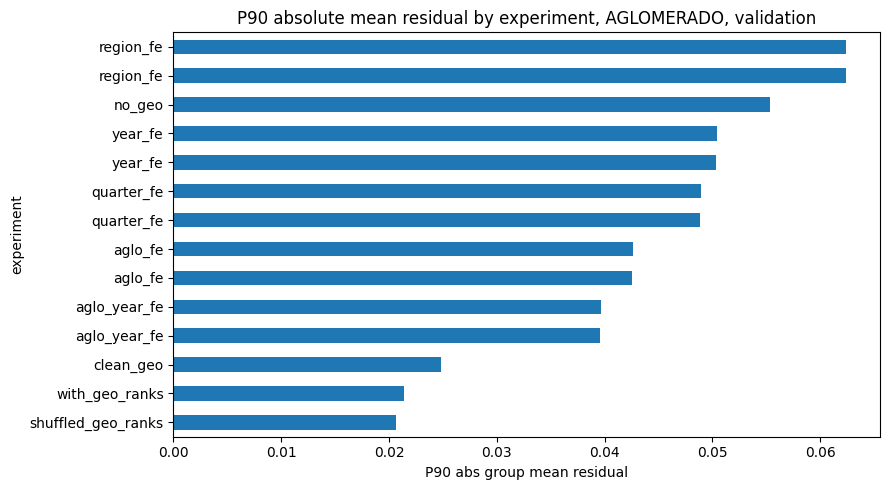

In [8]:
plot_df = (
    effect_magnitude_summary
    .query("split == 'validation' and group_type == @GEO_COL")
    .copy()
    .sort_values("p90_abs_effect")
)

if not plot_df.empty:
    ax = plot_df.plot.barh(
        x="experiment",
        y="p90_abs_effect",
        figsize=(9, 5),
        title=f"P90 absolute mean residual by experiment, {GEO_COL}, {SPLIT}",
        legend=False,
    )
    ax.set_xlabel("P90 abs group mean residual")
    plt.tight_layout()

highlight_groups.round(4)

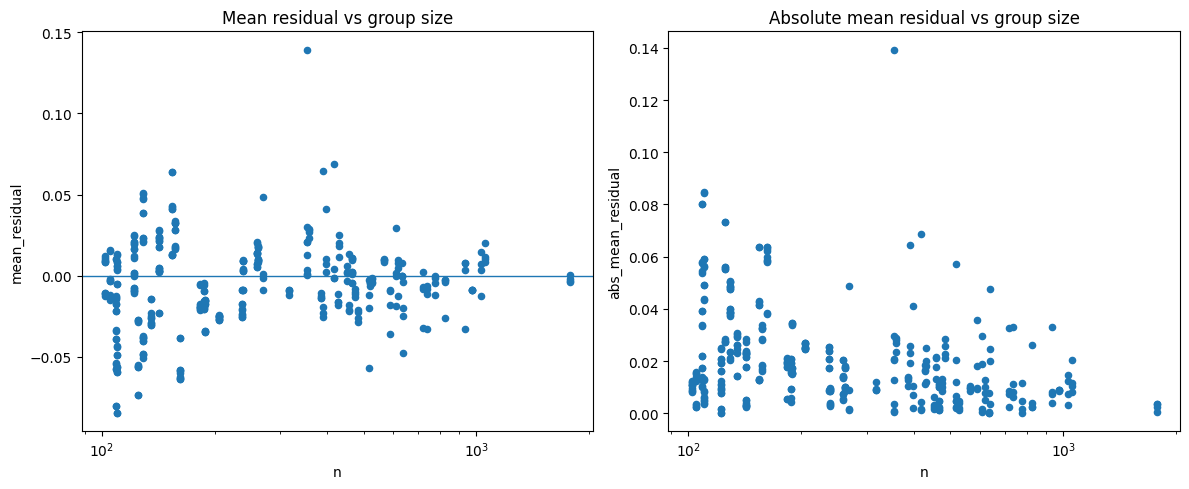

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

if not df_group_big.empty:
    df_group_big.plot.scatter(
        x="n",
        y="mean_residual",
        ax=axes[0],
        title="Mean residual vs group size",
    )
    axes[0].axhline(0, linewidth=1)
    axes[0].set_xscale("log")

    df_group_big.plot.scatter(
        x="n",
        y="abs_mean_residual",
        ax=axes[1],
        title="Absolute mean residual vs group size",
    )
    axes[1].set_xscale("log")

plt.tight_layout()

## 06. Geographic variance decomposition

Question: how much of outcome/residual variation is explained by group-level residual effects?

This is not a causal decomposition. It is a descriptive scale check:

```text
share_var_y = Var(group mean residual assigned to each observation) / Var(y_true)
```

In [10]:
def weighted_var(x, w=None):
    x = np.asarray(x, dtype=float)
    if w is None:
        return np.nanvar(x)
    w = np.asarray(w, dtype=float)
    mask = np.isfinite(x) & np.isfinite(w)
    if mask.sum() == 0:
        return np.nan
    mu = np.average(x[mask], weights=w[mask])
    return np.average((x[mask] - mu) ** 2, weights=w[mask])


rows = []

for (experiment, model, split, group_type), df_g in group_residual_summary.groupby(
    ["experiment", "model", "split", "group_type"], dropna=False
):
    if group_type not in predictions_geo.columns:
        continue

    df_obs = predictions_geo.query(
        "experiment == @experiment and model == @model and split == @split"
    ).copy()

    group_effect_map = df_g.set_index("group_value")["mean_residual"]
    df_obs["_group_key"] = df_obs[group_type].astype(str)
    effect_map = group_effect_map.copy()
    effect_map.index = effect_map.index.astype(str)
    df_obs["group_mean_residual"] = df_obs["_group_key"].map(effect_map)

    var_y = weighted_var(df_obs["y_true"])
    var_pred = weighted_var(df_obs["y_pred"])
    var_resid = weighted_var(df_obs["residual"])
    var_group_resid = weighted_var(df_obs["group_mean_residual"])

    rows.append({
        "experiment": experiment,
        "model": model,
        "split": split,
        "group_type": group_type,
        "var_y": var_y,
        "var_pred": var_pred,
        "var_residual": var_resid,
        "var_group_mean_residual": var_group_resid,
        "share_var_y": var_group_resid / var_y if var_y else np.nan,
        "share_var_residual": var_group_resid / var_resid if var_resid else np.nan,
    })

geo_variance_decomposition = pd.DataFrame(rows)
geo_var = geo_variance_decomposition.copy()

if not geo_var.empty:
    geo_var["sd_y"] = np.sqrt(geo_var["var_y"])
    geo_var["sd_pred"] = np.sqrt(geo_var["var_pred"])
    geo_var["sd_residual"] = np.sqrt(geo_var["var_residual"])
    geo_var["sd_group_mean_residual"] = np.sqrt(geo_var["var_group_mean_residual"])
    geo_var["share_var_y_pct"] = 100 * geo_var["share_var_y"]
    geo_var["share_var_residual_pct"] = 100 * geo_var["share_var_residual"]

geo_var.round(6).head()

,experiment,model,split,group_type,var_y,var_pred,var_residual,var_group_mean_residual,share_var_y,share_var_residual,sd_y,sd_pred,sd_residual,sd_group_mean_residual,share_var_y_pct,share_var_residual_pct
0,aglo_fe,LinearRegression,test,AGLOMERADO,0.142588,0.059275,0.080995,0.000412,0.002892,0.005091,0.377609,0.243464,0.284596,0.020306,0.289167,0.509067
1,aglo_fe,LinearRegression,test,Region,0.142588,0.059275,0.080995,0.000023,0.000163,0.000286,0.377609,0.243464,0.284596,0.004815,0.016260,0.028624
2,aglo_fe,LinearRegression,validation,AGLOMERADO,0.148690,0.059295,0.084966,0.000636,0.004277,0.007484,0.385603,0.243505,0.291489,0.025217,0.427664,0.748410
3,aglo_fe,LinearRegression,validation,Region,0.148690,0.059295,0.084966,0.000037,0.000246,0.000430,0.385603,0.243505,0.291489,0.006043,0.024561,0.042981
4,aglo_fe,Ridge,test,AGLOMERADO,0.142588,0.059101,0.080979,0.000414,0.002900,0.005106,0.377609,0.243107,0.284568,0.020335,0.290001,0.510636


## 07. Substance tables

These tables translate variance shares into interpretable scale checks.

In [11]:
def classify_share(x):
    if pd.isna(x):
        return "missing"
    if x < 0.1:
        return "near zero"
    if x < 0.5:
        return "small"
    if x < 1.0:
        return "moderate-small"
    if x < 3.0:
        return "moderate"
    return "large/outlier"


substance = (
    geo_var
    .assign(
        sd_geo=lambda d: np.sqrt(d["var_group_mean_residual"]),
        sd_y=lambda d: np.sqrt(d["var_y"]),
        sd_resid=lambda d: np.sqrt(d["var_residual"]),
        geo_sd_as_pct_y_sd=lambda d: 100 * d["sd_geo"] / d["sd_y"],
        share_y_pct=lambda d: 100 * d["share_var_y"],
        share_resid_pct=lambda d: 100 * d["share_var_residual"],
    )
    [[
        "experiment", "model", "split", "group_type",
        "sd_geo", "geo_sd_as_pct_y_sd",
        "share_y_pct", "share_resid_pct",
        "sd_y", "sd_resid"
    ]]
    .copy()
)

substance["magnitude_class"] = substance["share_y_pct"].apply(classify_share)

substance_validation = (
    substance
    .query("split == 'validation'")
    .sort_values(["group_type", "share_y_pct"], ascending=[True, False])
)

substance_validation.round(4)

,experiment,model,split,group_type,sd_geo,geo_sd_as_pct_y_sd,share_y_pct,share_resid_pct,sd_y,sd_resid,magnitude_class
22,no_geo,HistGradientBoostingRegressor,validation,AGLOMERADO,0.0326,8.6258,0.7440,1.6905,0.3774,0.2504,moderate-small
34,region_fe,LinearRegression,validation,AGLOMERADO,0.0322,8.3376,0.6952,1.2114,0.3856,0.2921,moderate-small
38,region_fe,Ridge,validation,AGLOMERADO,0.0321,8.3361,0.6949,1.2106,0.3856,0.2922,moderate-small
30,quarter_fe,Ridge,validation,AGLOMERADO,0.0264,6.8526,0.4696,0.8248,0.3856,0.2910,small
26,quarter_fe,LinearRegression,validation,AGLOMERADO,0.0264,6.8506,0.4693,0.8246,0.3856,0.2909,small
54,year_fe,Ridge,validation,AGLOMERADO,0.0261,6.7780,0.4594,0.8145,0.3856,0.2896,small
50,year_fe,LinearRegression,validation,AGLOMERADO,0.0260,6.7522,0.4559,0.8083,0.3856,0.2896,small
2,aglo_fe,LinearRegression,validation,AGLOMERADO,0.0252,6.5396,0.4277,0.7484,0.3856,0.2915,small
6,aglo_fe,Ridge,validation,AGLOMERADO,0.0251,6.5133,0.4242,0.7421,0.3856,0.2915,small
10,aglo_year_fe,LinearRegression,validation,AGLOMERADO,0.0245,6.3553,0.4039,0.7142,0.3856,0.2900,small


In [12]:
geo_level_compare = (
    geo_var
    .pivot_table(
        index=["experiment", "model", "split"],
        columns="group_type",
        values=["share_var_y", "share_var_residual", "var_group_mean_residual"],
        aggfunc="first",
    )
)

geo_level_compare.columns = [f"{a}_{b}" for a, b in geo_level_compare.columns]
geo_level_compare = geo_level_compare.reset_index()

if {"share_var_y_AGLOMERADO", "share_var_y_Region"}.issubset(geo_level_compare.columns):
    geo_level_compare["aglo_over_region_share_y"] = (
        geo_level_compare["share_var_y_AGLOMERADO"]
        / geo_level_compare["share_var_y_Region"]
    )
elif {"share_var_y_AGLOMERADO", "share_var_y_REGION"}.issubset(geo_level_compare.columns):
    geo_level_compare["aglo_over_region_share_y"] = (
        geo_level_compare["share_var_y_AGLOMERADO"]
        / geo_level_compare["share_var_y_REGION"]
    )

# Region column may be named Region or REGION in the processed data.
region_share_col = "share_var_y_Region" if "share_var_y_Region" in geo_level_compare.columns else "share_var_y_REGION"

if {"share_var_y_AGLOMERADO", region_share_col}.issubset(geo_level_compare.columns):
    aglo_region_check = (
        geo_level_compare
        .assign(
            aglo_share_y_pct=lambda d: 100 * d["share_var_y_AGLOMERADO"],
            region_share_y_pct=lambda d: 100 * d[region_share_col],
            aglo_minus_region_pct=lambda d: 100 * (d["share_var_y_AGLOMERADO"] - d[region_share_col]),
        )
        [[
            "experiment", "model", "split",
            "aglo_share_y_pct", "region_share_y_pct",
            "aglo_over_region_share_y", "aglo_minus_region_pct",
        ]]
        .sort_values("aglo_minus_region_pct", ascending=False)
    )
else:
    aglo_region_check = pd.DataFrame()

aglo_region_check.round(4)

,experiment,model,split,aglo_share_y_pct,region_share_y_pct,aglo_over_region_share_y,aglo_minus_region_pct
18,region_fe,Ridge,test,0.7488,0.0170,44.1236,0.7318
16,region_fe,LinearRegression,test,0.7483,0.0170,44.0110,0.7313
19,region_fe,Ridge,validation,0.6949,0.0260,26.6791,0.6689
17,region_fe,LinearRegression,validation,0.6952,0.0263,26.3831,0.6688
14,quarter_fe,Ridge,test,0.6134,0.0175,35.0927,0.5959
12,quarter_fe,LinearRegression,test,0.6129,0.0175,35.0558,0.5954
26,year_fe,Ridge,test,0.6095,0.0190,32.1183,0.5906
24,year_fe,LinearRegression,test,0.6026,0.0173,34.8354,0.5853
15,quarter_fe,Ridge,validation,0.4696,0.0315,14.8857,0.4380
13,quarter_fe,LinearRegression,validation,0.4693,0.0318,14.7544,0.4375


In [13]:
split_stability = (
    geo_var
    .pivot_table(
        index=["experiment", "model", "group_type"],
        columns="split",
        values="share_var_y",
        aggfunc="first",
    )
    .reset_index()
)

if {"test", "validation"}.issubset(split_stability.columns):
    stability_check = (
        split_stability
        .assign(
            test_pct=lambda d: 100 * d["test"],
            validation_pct=lambda d: 100 * d["validation"],
            abs_diff_pct=lambda d: (d["validation_pct"] - d["test_pct"]).abs(),
            rel_change=lambda d: d["validation"] / d["test"],
        )
        [[
            "experiment", "model", "group_type",
            "test_pct", "validation_pct", "abs_diff_pct", "rel_change",
        ]]
        .sort_values("abs_diff_pct", ascending=False)
    )
else:
    stability_check = pd.DataFrame()

stability_check.round(4)

split,experiment,model,group_type,test_pct,validation_pct,abs_diff_pct,rel_change
26,year_fe,Ridge,AGLOMERADO,0.6095,0.4594,0.1501,0.7537
24,year_fe,LinearRegression,AGLOMERADO,0.6026,0.4559,0.1467,0.7566
14,quarter_fe,Ridge,AGLOMERADO,0.6134,0.4696,0.1438,0.7656
12,quarter_fe,LinearRegression,AGLOMERADO,0.6129,0.4693,0.1436,0.7657
0,aglo_fe,LinearRegression,AGLOMERADO,0.2892,0.4277,0.1385,1.4790
6,aglo_year_fe,Ridge,AGLOMERADO,0.2644,0.4019,0.1375,1.5199
4,aglo_year_fe,LinearRegression,AGLOMERADO,0.2664,0.4039,0.1375,1.5160
2,aglo_fe,Ridge,AGLOMERADO,0.2900,0.4242,0.1342,1.4629
10,no_geo,HistGradientBoostingRegressor,AGLOMERADO,0.8735,0.7440,0.1295,0.8518
18,region_fe,Ridge,AGLOMERADO,0.7488,0.6949,0.0539,0.9281


In [14]:
ridge_ols_check = (
    geo_var
    .query("model in ['LinearRegression', 'Ridge']")
    .pivot_table(
        index=["experiment", "split", "group_type"],
        columns="model",
        values="share_var_y",
        aggfunc="first",
    )
    .reset_index()
)

if {"LinearRegression", "Ridge"}.issubset(ridge_ols_check.columns):
    ridge_ols_check["ridge_minus_ols_pct"] = 100 * (
        ridge_ols_check["Ridge"] - ridge_ols_check["LinearRegression"]
    )
    ridge_ols_check["ridge_over_ols"] = (
        ridge_ols_check["Ridge"] / ridge_ols_check["LinearRegression"]
    )

ridge_ols_check.sort_values(
    "ridge_minus_ols_pct" if "ridge_minus_ols_pct" in ridge_ols_check.columns else "experiment",
    key=lambda s: s.abs() if pd.api.types.is_numeric_dtype(s) else s,
    ascending=False,
).round(6)

model,experiment,split,group_type,LinearRegression,Ridge,ridge_minus_ols_pct,ridge_over_ols
16,year_fe,test,AGLOMERADO,0.006026,0.006095,0.006965,1.011559
18,year_fe,validation,AGLOMERADO,0.004559,0.004594,0.003489,1.007653
2,aglo_fe,validation,AGLOMERADO,0.004277,0.004242,-0.003434,0.991970
4,aglo_year_fe,test,AGLOMERADO,0.002664,0.002644,-0.002007,0.992467
6,aglo_year_fe,validation,AGLOMERADO,0.004039,0.004019,-0.002001,0.995045
17,year_fe,test,Region,0.000173,0.000190,0.001680,1.097132
0,aglo_fe,test,AGLOMERADO,0.002892,0.002900,0.000834,1.002883
7,aglo_year_fe,validation,Region,0.000271,0.000263,-0.000824,0.969588
1,aglo_fe,test,Region,0.000163,0.000170,0.000758,1.046638
5,aglo_year_fe,test,Region,0.000175,0.000182,0.000723,1.041357


## 08. Variance decomposition plots

The first plot is the main candidate figure from this notebook: geographic share of outcome variance by experiment.

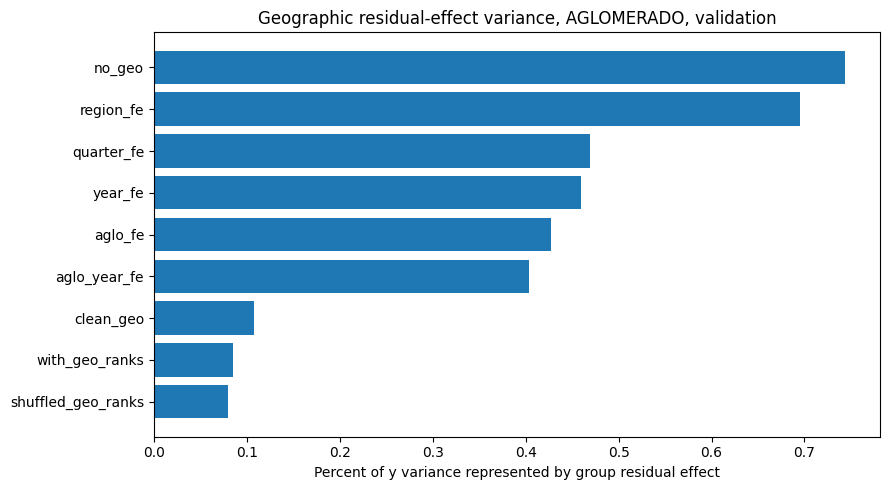

In [15]:
plot_df = (
    substance
    .query("split == 'validation' and group_type == @GEO_COL")
    .sort_values("share_y_pct")
)

if not plot_df.empty:
    plt.figure(figsize=(9, 5))
    plt.barh(plot_df["experiment"], plot_df["share_y_pct"])
    plt.xlabel("Percent of y variance represented by group residual effect")
    plt.title(f"Geographic residual-effect variance, {GEO_COL}, validation")
    plt.tight_layout()
else:
    print("No data available for variance plot.")

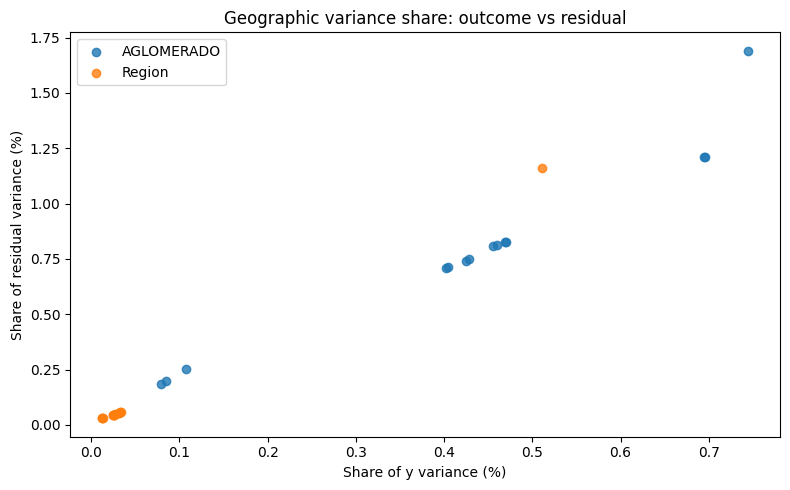

In [16]:
plot_df = (
    substance
    .query("split == 'validation'")
    .copy()
)

if not plot_df.empty:
    plt.figure(figsize=(8, 5))
    for group_type, tmp in plot_df.groupby("group_type"):
        plt.scatter(
            tmp["share_y_pct"],
            tmp["share_resid_pct"],
            label=group_type,
            alpha=0.8,
        )

    plt.xlabel("Share of y variance (%)")
    plt.ylabel("Share of residual variance (%)")
    plt.title("Geographic variance share: outcome vs residual")
    plt.legend()
    plt.tight_layout()
else:
    print("No data available for diagnostic scatter.")

## 09. Real vs shuffled ranks

Question: do real geographic ranks outperform the shuffled-placebo ranks in a substantively meaningful way?

In [17]:
rank_geo_check = (
    geo_var
    .query("experiment in ['with_geo_ranks', 'shuffled_geo_ranks']")
    .pivot_table(
        index=["model", "split", "group_type"],
        columns="experiment",
        values="share_var_y",
        aggfunc="first",
    )
    .reset_index()
)

if {"with_geo_ranks", "shuffled_geo_ranks"}.issubset(rank_geo_check.columns):
    rank_geo_check["real_minus_shuffled_pct"] = 100 * (
        rank_geo_check["with_geo_ranks"] - rank_geo_check["shuffled_geo_ranks"]
    )
    rank_geo_check["real_over_shuffled"] = (
        rank_geo_check["with_geo_ranks"] / rank_geo_check["shuffled_geo_ranks"]
    )

rank_geo_check.round(5)

experiment,model,split,group_type,shuffled_geo_ranks,with_geo_ranks,real_minus_shuffled_pct,real_over_shuffled
0,HistGradientBoostingRegressor,test,AGLOMERADO,0.00081,0.00066,-0.01536,0.81012
1,HistGradientBoostingRegressor,test,Region,0.00004,0.00001,-0.00288,0.32022
2,HistGradientBoostingRegressor,validation,AGLOMERADO,0.00080,0.00085,0.00502,1.06303
3,HistGradientBoostingRegressor,validation,Region,0.00013,0.00013,-0.00010,0.99244


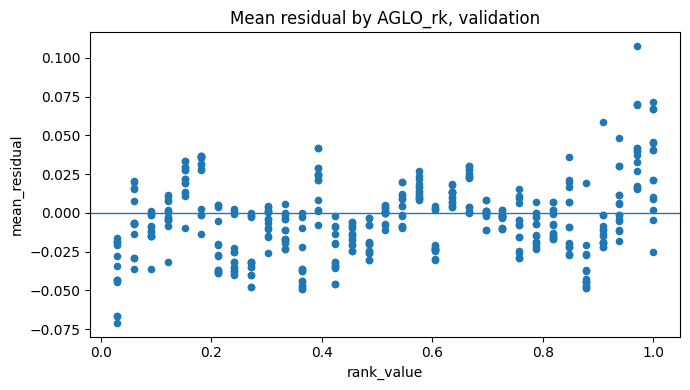

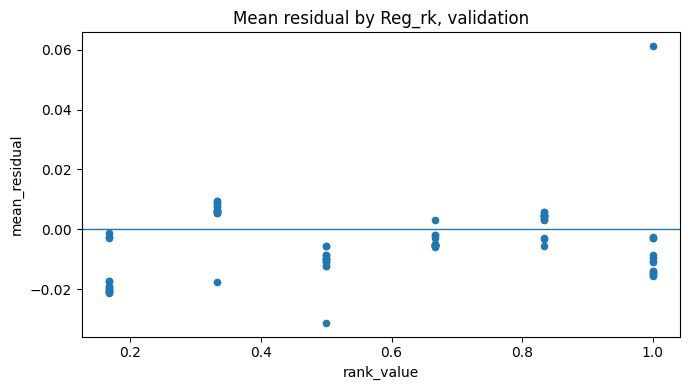

In [18]:
if not rank_summary.empty:
    df_rank = rank_summary.query("split == 'validation'").copy()
    df_rank["abs_mean_residual"] = df_rank["mean_residual"].abs()

    for rank_type in df_rank["rank_type"].dropna().unique():
        tmp = df_rank.query("rank_type == @rank_type")
        ax = tmp.plot.scatter(
            x="rank_value",
            y="mean_residual",
            figsize=(7, 4),
            title=f"Mean residual by {rank_type}, validation",
        )
        ax.axhline(0, linewidth=1)
        plt.tight_layout()
else:
    print("No rank_summary available. Check whether AGLO_rk or Reg_rk were merged.")

## 10. Stability of geographic residual effects across settings

Question: do the same agglomerates appear high/low across model variants?

In [19]:
df_stability = (
    group_residual_summary
    .query("split == @SPLIT and group_type == @GEO_COL")
    [["experiment", "model", "group_value", "mean_residual", "n"]]
    .copy()
)

df_stability["group_value"] = df_stability["group_value"].astype(str)
df_stability["setting"] = df_stability["experiment"] + " | " + df_stability["model"]

df_stability_wide = (
    df_stability
    .pivot_table(
        index="group_value",
        columns="setting",
        values="mean_residual",
        aggfunc="first",
    )
)

# Keep only groups with enough information across settings.
min_non_null_settings = min(3, len(df_stability_wide.columns))
df_stability_wide = df_stability_wide.dropna(thresh=min_non_null_settings)

fe_corr = df_stability_wide.corr()

fe_corr.round(3)

setting,aglo_fe | LinearRegression,aglo_fe | Ridge,aglo_year_fe | LinearRegression,aglo_year_fe | Ridge,clean_geo | HistGradientBoostingRegressor,no_geo | HistGradientBoostingRegressor,quarter_fe | LinearRegression,quarter_fe | Ridge,region_fe | LinearRegression,region_fe | Ridge,shuffled_geo_ranks | HistGradientBoostingRegressor,with_geo_ranks | HistGradientBoostingRegressor,year_fe | LinearRegression,year_fe | Ridge
setting,,,,,,,,,,,,,,
aglo_fe | LinearRegression,1.000,1.000,0.996,0.996,0.299,0.040,0.814,0.814,0.688,0.688,0.369,0.285,0.810,0.806
aglo_fe | Ridge,1.000,1.000,0.996,0.996,0.309,0.048,0.817,0.817,0.693,0.694,0.379,0.294,0.813,0.809
aglo_year_fe | LinearRegression,0.996,0.996,1.000,1.000,0.289,0.035,0.811,0.811,0.677,0.678,0.368,0.277,0.812,0.808
aglo_year_fe | Ridge,0.996,0.996,1.000,1.000,0.297,0.058,0.814,0.814,0.688,0.688,0.376,0.280,0.815,0.811
clean_geo | HistGradientBoostingRegressor,0.299,0.309,0.289,0.297,1.000,0.493,0.453,0.452,0.559,0.558,0.947,0.837,0.461,0.451
no_geo | HistGradientBoostingRegressor,0.040,0.048,0.035,0.058,0.493,1.000,0.226,0.227,0.394,0.394,0.446,0.286,0.230,0.216
quarter_fe | LinearRegression,0.814,0.817,0.811,0.814,0.453,0.226,1.000,1.000,0.853,0.854,0.453,0.321,0.995,0.995
quarter_fe | Ridge,0.814,0.817,0.811,0.814,0.452,0.227,1.000,1.000,0.854,0.854,0.453,0.320,0.995,0.995
region_fe | LinearRegression,0.688,0.693,0.677,0.688,0.559,0.394,0.853,0.854,1.000,1.000,0.557,0.291,0.853,0.843


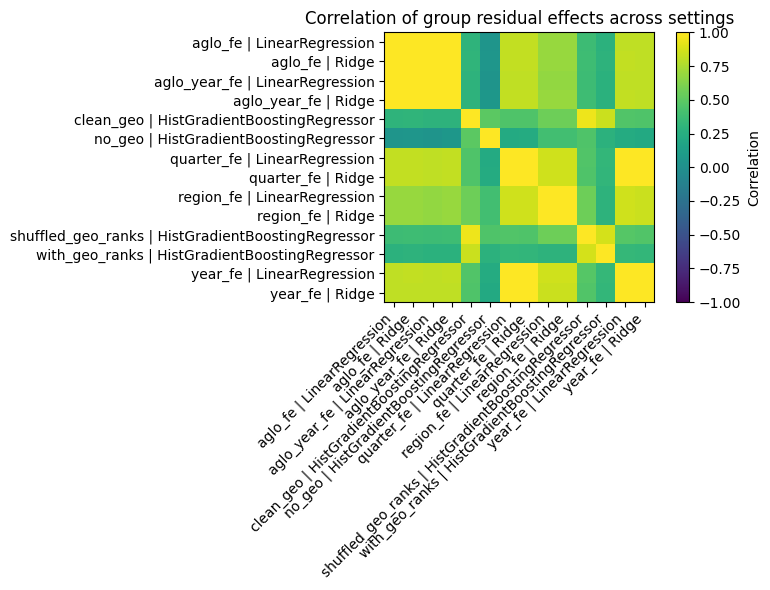

In [20]:
if not fe_corr.empty:
    plt.figure(figsize=(8, 6))
    plt.imshow(fe_corr, vmin=-1, vmax=1)
    plt.colorbar(label="Correlation")
    plt.xticks(range(len(fe_corr.columns)), fe_corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(fe_corr.index)), fe_corr.index)
    plt.title("Correlation of group residual effects across settings")
    plt.tight_layout()
else:
    print("No correlation matrix available.")

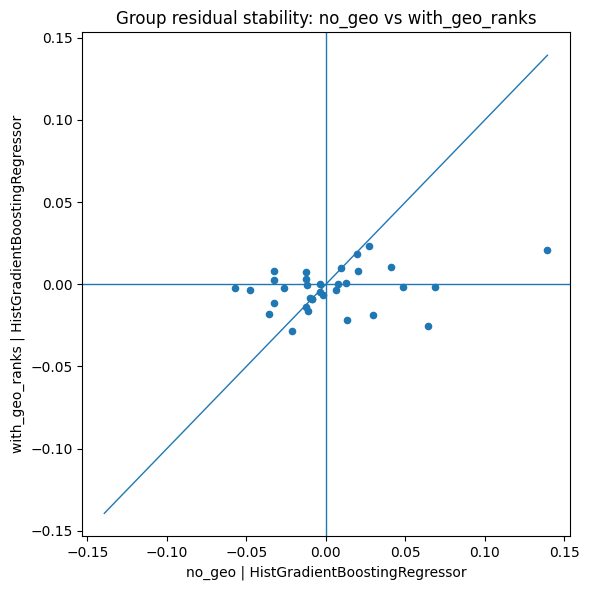

In [21]:
SCATTER_X = "no_geo | HistGradientBoostingRegressor"
SCATTER_Y = "with_geo_ranks | HistGradientBoostingRegressor"

if {SCATTER_X, SCATTER_Y}.issubset(df_stability_wide.columns):
    ax = df_stability_wide.plot.scatter(
        x=SCATTER_X,
        y=SCATTER_Y,
        figsize=(6, 6),
        title="Group residual stability: no_geo vs with_geo_ranks",
    )
    lim = np.nanmax(np.abs(df_stability_wide[[SCATTER_X, SCATTER_Y]].to_numpy()))
    ax.plot([-lim, lim], [-lim, lim], linewidth=1)
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    plt.tight_layout()
else:
    print("Requested scatter settings not available:", SCATTER_X, SCATTER_Y)

## 11. Aglomerate narrative plots

Question: does the residual-effect profile simply follow the raw income ranking, or does it tell a different story?

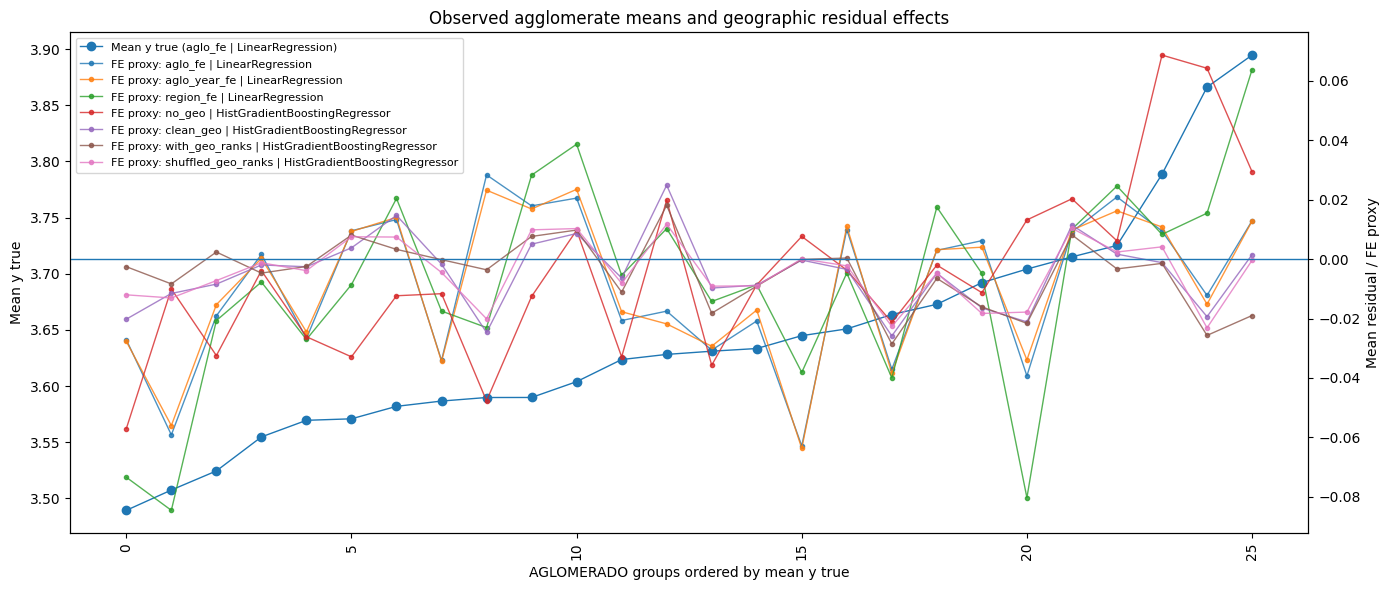

In [22]:
SETTINGS_TO_PLOT = [
    "aglo_fe | LinearRegression",
    "aglo_year_fe | LinearRegression",
    "region_fe | LinearRegression",
    "no_geo | HistGradientBoostingRegressor",
    "clean_geo | HistGradientBoostingRegressor",
    "with_geo_ranks | HistGradientBoostingRegressor",
    "shuffled_geo_ranks | HistGradientBoostingRegressor",
]

SETTINGS_TO_PLOT = [s for s in SETTINGS_TO_PLOT if s in df_group_big["setting"].unique()]

df_ref = (
    df_group_big
    .query("setting == @REFERENCE_SETTING")
    .sort_values("group_order")
    .copy()
)

x = np.arange(len(df_ref))

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(
    x,
    df_ref["mean_y_true"],
    marker="o",
    linewidth=1,
    label=f"Mean y true ({REFERENCE_SETTING})",
)

ax1.set_ylabel("Mean y true")
ax1.set_xlabel(f"{GEO_COL} groups ordered by mean y true")
ax1.set_title("Observed agglomerate means and geographic residual effects")
ax1.tick_params(axis="x", labelrotation=90)

ax2 = ax1.twinx()

for setting in SETTINGS_TO_PLOT:
    tmp = (
        df_group_big
        .query("setting == @setting")
        .sort_values("group_order")
    )
    tmp = tmp.set_index("group_value").reindex(df_ref["group_value"]).reset_index()

    ax2.plot(
        x,
        tmp["mean_residual"],
        marker=".",
        linewidth=1,
        alpha=0.8,
        label=f"FE proxy: {setting}",
    )

ax2.axhline(0, linewidth=1)
ax2.set_ylabel("Mean residual / FE proxy")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=8)

plt.tight_layout()
plt.show()

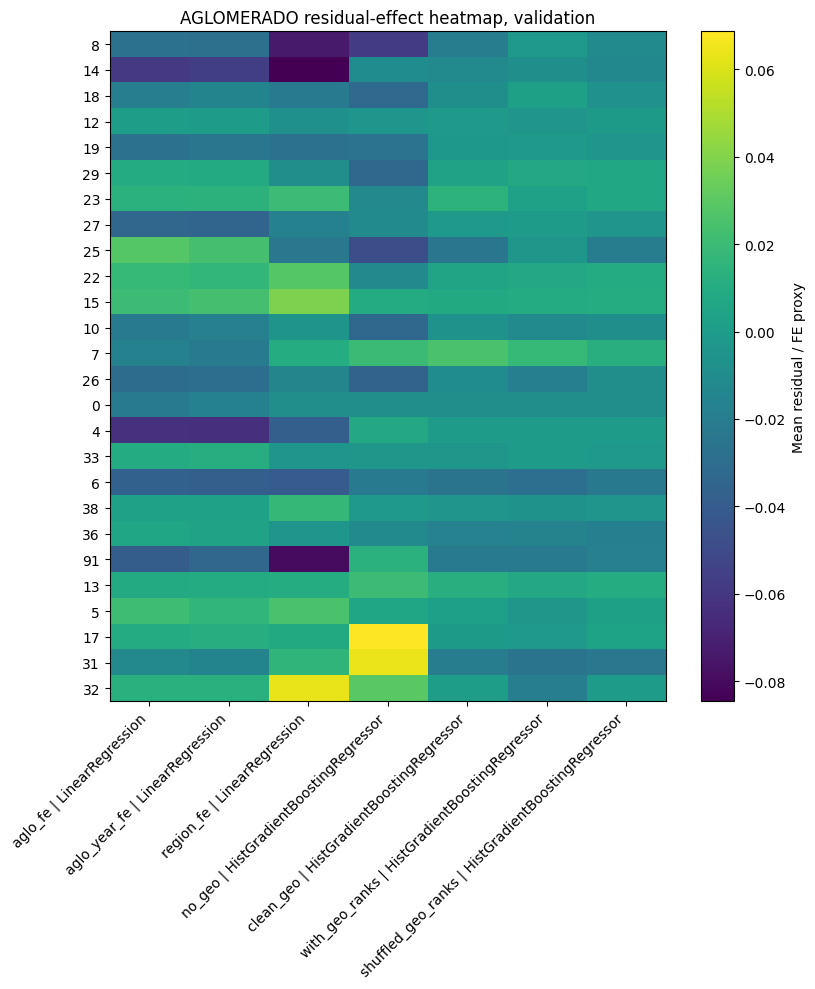

In [23]:
# Heatmap of group residuals by setting.
if not df_stability_wide.empty:
    # Use order from the reference setting when possible.
    heatmap_df = df_stability_wide.copy()
    heatmap_order = [g for g in order if g in heatmap_df.index]
    heatmap_df = heatmap_df.loc[heatmap_order]

    # Keep a readable subset of settings if there are many.
    heatmap_cols = [c for c in SETTINGS_TO_PLOT if c in heatmap_df.columns]
    if not heatmap_cols:
        heatmap_cols = heatmap_df.columns.tolist()[:8]

    plt.figure(figsize=(max(8, len(heatmap_cols) * 1.2), 10))
    plt.imshow(heatmap_df[heatmap_cols], aspect="auto")
    plt.colorbar(label="Mean residual / FE proxy")
    plt.xticks(range(len(heatmap_cols)), heatmap_cols, rotation=45, ha="right")
    plt.yticks(range(len(heatmap_df.index)), heatmap_df.index)
    plt.title(f"{GEO_COL} residual-effect heatmap, {SPLIT}")
    plt.tight_layout()
else:
    print("No df_stability_wide available for heatmap.")

## 12. Top contributors

Question: which groups contribute most to the geographic residual-effect variance?

In [24]:
df_aglo_contrib = df_group_big.copy()

df_aglo_contrib["weight"] = (
    df_aglo_contrib["n"]
    / df_aglo_contrib.groupby("setting")["n"].transform("sum")
)

df_aglo_contrib["variance_contribution"] = (
    df_aglo_contrib["weight"] * df_aglo_contrib["mean_residual"] ** 2
)

top_contributors = (
    df_aglo_contrib
    .sort_values(["setting", "variance_contribution"], ascending=[True, False])
    .groupby("setting")
    .head(10)
    [[
        "setting",
        "group_value",
        "n",
        "mean_y_true",
        "mean_y_pred",
        "mean_residual",
        "abs_mean_residual",
        "variance_contribution",
    ]]
)

top_contributors.round(4)

,setting,group_value,n,mean_y_true,mean_y_pred,mean_residual,abs_mean_residual,variance_contribution
36,aglo_fe | LinearRegression,4,162,3.6449,3.7077,-0.0629,0.0629,0.0001
45,aglo_fe | LinearRegression,14,110,3.5075,3.5666,-0.0592,0.0592,0.0001
55,aglo_fe | LinearRegression,27,189,3.5867,3.6208,-0.0341,0.0341,0.0001
38,aglo_fe | LinearRegression,6,129,3.6637,3.7008,-0.0371,0.0371,0.0000
64,aglo_fe | LinearRegression,91,109,3.7041,3.7434,-0.0393,0.0393,0.0000
...,...,...,...,...,...,...,...,...
917,year_fe | Ridge,32,154,3.8946,3.8515,0.0431,0.0431,0.0001
903,year_fe | Ridge,14,110,3.5075,3.5514,-0.0439,0.0439,0.0000
909,year_fe | Ridge,22,157,3.5899,3.5562,0.0336,0.0336,0.0000
891,year_fe | Ridge,0,237,3.6334,3.6574,-0.0240,0.0240,0.0000


## 13. Final findings object

This is a compact object for downstream notes. Fill `main_interpretation` manually after reviewing the plots.

In [25]:
GEO_FINDINGS = {
    "delta_r2_vs_no_geo": (
        geo_comparison.set_index("experiment")["delta_validation_r2_vs_no_geo"].to_dict()
        if "delta_validation_r2_vs_no_geo" in geo_comparison.columns
        else None
    ),
    "real_vs_shuffled": real_vs_shuffled.to_dict("records") if not real_vs_shuffled.empty else [],
    "effect_magnitude_summary": effect_magnitude_summary.to_dict("records"),
    "variance_decomposition": geo_variance_decomposition.to_dict("records"),
    "substance_validation": substance_validation.to_dict("records"),
    "main_interpretation": "",
    "backend_candidates": [
        "group_residual_summary",
        "geo_variance_decomposition",
        "effect_magnitude_summary",
        "rank_geo_check",
    ],
}

GEO_FINDINGS

{'delta_r2_vs_no_geo': {'clean_geo': 0.011591000312959121,
  'no_geo': 0.0,
  'with_geo_ranks': 0.013207196388920317,
  'shuffled_geo_ranks': 0.013329727364076671,
  'region_fe': -0.1340194049943082,
  'aglo_fe': -0.13166466248613368,
  'year_fe': -0.12406023939459587,
  'quarter_fe': -0.1293722629561333,
  'aglo_year_fe': -0.1255931361619586},
 'real_vs_shuffled': [{'metric': 'validation_r2',
   'real_geo_ranks': 0.5730352404413822,
   'shuffled_geo_ranks': 0.5731577714165386,
   'real_minus_shuffled': -0.00012253097515635414},
  {'metric': 'validation_mae',
   'real_geo_ranks': 0.1813652833111229,
   'shuffled_geo_ranks': 0.1814644366615521,
   'real_minus_shuffled': -9.915335042920415e-05}],
 'effect_magnitude_summary': [{'experiment': 'aglo_fe',
   'model': 'LinearRegression',
   'split': 'test',
   'group_type': 'AGLOMERADO',
   'n_groups': 33.0,
   'total_n': 10000.0,
   'median_abs_effect': 0.015575880892719702,
   'mean_abs_effect': 0.018329985695652137,
   'p75_abs_effect': 0.

In [26]:
# Optional: save notebook-derived tables as exploratory artifacts.
# These are not backend outputs yet. They are notebook exploration outputs.

tables_to_save = {
    "geo_model_table.csv": geo_model_table,
    "effect_magnitude_summary.csv": effect_magnitude_summary,
    "geo_variance_decomposition.csv": geo_variance_decomposition,
    "substance_validation.csv": substance_validation,
    "rank_geo_check.csv": rank_geo_check,
    "stability_check.csv": stability_check,
    "top_contributors.csv": top_contributors,
}

for filename, df in tables_to_save.items():
    if isinstance(df, pd.DataFrame) and not df.empty:
        df.to_csv(OUTPUT_DIR / filename, index=False)

print("Saved exploratory tables to:", OUTPUT_DIR)

Saved exploratory tables to: /home/matias/repos/income-modeling-eph/reports/notebook_outputs/geo_effects_and_ranks
